In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem

import torch
import umap
import matplotlib.pyplot as plt

/root/ReactionT5-bo-yield/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## データの読み込み

In [2]:
# すべてのデータセットを読み込み
datasets = {
    'Buchwald-Hartwig': '../data/Buchwald-Hartwig/Dreher_and_Doyle_reaction_t5_ready.csv',
    'NiB': '../data/NiB/inchi_23l_reaction_t5_ready.csv',
    'Suzuki-Miyaura': '../data/Suzuki-Miyaura/aap9112_reaction_t5_ready.csv',
    'ORD': '../data/ORD/all_ord_reaction_uniq_with_attr20240506_v3_train.csv', 
}

dfs = {}
failed_datasets = []

for name, path in datasets.items():
    try:
        dfs[name] = pd.read_csv(path)
        print(f"Loaded {name}: {len(dfs[name])} rows")
        
        # ORDデータセットの場合、重要なカラムに欠損値がある行を削除
        if name == 'ORD':
            required_cols = ['REACTANT', 'PRODUCT', 'YIELD']  # YIELDも必須に追加
            before_count = len(dfs[name])
            dfs[name] = dfs[name].dropna(subset=required_cols)
            after_count = len(dfs[name])
            print(f"  Dropped {before_count - after_count} rows with missing values in required columns")
            print(f"  Remaining: {after_count} rows")

        if name !='CN':
            dfs[name]["REAGENT"] = dfs[name]["CATALYST"].fillna(" ") + "." + dfs[name]["REAGENT"].fillna(" ") + "." + dfs[name]["SOLVENT"].fillna(" ") 
        
    except FileNotFoundError:
        print(f"Error: File not found for {name}: {path}")
        failed_datasets.append(name)
    except pd.errors.EmptyDataError:
        print(f"Error: Empty file for {name}: {path}")
        failed_datasets.append(name)
    except Exception as e:
        print(f"Error loading {name}: {e}")
        failed_datasets.append(name)

# 失敗したデータセットがあれば警告
if failed_datasets:
    print(f"\n警告: 以下のデータセットの読み込みに失敗しました: {', '.join(failed_datasets)}")
    print("処理を継続しますが、これらのデータセットは分析に含まれません。")

Loaded Buchwald-Hartwig: 1980 rows
Loaded NiB: 1518 rows
Loaded Suzuki-Miyaura: 3696 rows
Loaded ORD: 1819521 rows
  Dropped 1274245 rows with missing values in required columns
  Remaining: 545276 rows


In [3]:
import os
from pathlib import Path

# SMILESをcanonical化する関数
def canonicalize_smiles(smiles_str):
    """RDKitを使ってSMILESをcanonical形式に変換。canonical化できない場合はNoneを返す。"""
    if pd.isna(smiles_str) or smiles_str == '':
        return ''
    
    # '.'で区切られた複数のSMILESを処理
    smiles_list = str(smiles_str).split('.')
    canonical_list = []
    
    for smi in smiles_list:
        smi = smi.strip()
        if smi == '' or smi == ' ':
            continue
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is not None:
                canonical_list.append(Chem.MolToSmiles(mol))
            else:
                # パースに失敗した場合、削除対象としてNoneを返す
                return None
        except:
            # エラーが発生した場合、削除対象としてNoneを返す
            return None
    
    # ソートして結合し、一貫した順序を保証
    return '.'.join(sorted(canonical_list))

# DataFrameの全SMILES列をcanonical化する関数
def canonicalize_dataframe(df, smiles_cols=['REACTANT', 'REAGENT', 'PRODUCT']):
    """DataFrameのSMILES列をcanonical化し、無効なSMILESを含む行を削除。
    canonical化されたSMILESを持つ新しいDataFrameを返す。"""
    
    # 利用可能な列をチェック
    available_cols = [col for col in smiles_cols if col in df.columns]
    if not available_cols:
        print(f"Warning: None of the specified columns {smiles_cols} found in dataframe")
        return df
    
    print(f"Canonicalizing SMILES columns: {available_cols}")
    
    # オリジナルを変更しないようにコピーを作成
    canonical_df = df.copy()
    
    # 各列をcanonical化
    for col in available_cols:
        print(f"  Processing {col}...")
        canonical_df[col] = canonical_df[col].apply(canonicalize_smiles)
    
    # None値（canonical化失敗）を含む行をカウントして削除
    none_mask = canonical_df[available_cols].isnull().any(axis=1)
    none_count = none_mask.sum()
    total_count = len(canonical_df)
    
    if none_count > 0:
        print(f"  無効なSMILESを含む{none_count}行を削除（全{total_count}行中）")
        canonical_df = canonical_df[~none_mask]
        print(f"  残り: {len(canonical_df)}行")
    else:
        print(f"  全{total_count}行が有効なSMILESです")
    
    return canonical_df

# canonical化されたCSVファイルのパスを取得する関数
def get_canonical_path(name, original_path):
    """データセット名と元のパスから、canonical化されたCSVファイルのパスを生成"""
    original_path = Path(original_path)
    dataset_dir = original_path.parent
    stem = original_path.stem.replace('_reaction_t5_ready', '')
    canonical_filename = f"{stem}_canonicalized.csv"
    return dataset_dir / canonical_filename

# 全データセットをcanonical化（キャッシュを利用）
canonical_dfs = {}
for name, df in dfs.items():
    # canonical化されたファイルのパスを取得
    canonical_path = get_canonical_path(name, datasets[name])
    
    # canonical化されたファイルが存在するかチェック
    if canonical_path.exists():
        print(f"\n{name}: Loading from cached file {canonical_path}")
        canonical_dfs[name] = pd.read_csv(canonical_path)
        print(f"  Loaded {len(canonical_dfs[name])} rows")
    else:
        print(f"\n{name}: Canonicalizing and saving to {canonical_path}")
        canonical_dfs[name] = canonicalize_dataframe(df)
        
        # canonical化されたデータを保存
        canonical_path.parent.mkdir(parents=True, exist_ok=True)
        canonical_dfs[name].to_csv(canonical_path, index=False)
        print(f"  Saved {len(canonical_dfs[name])} rows to {canonical_path}")

# 元のdfsを削除
del dfs


Buchwald-Hartwig: Loading from cached file ../data/Buchwald-Hartwig/Dreher_and_Doyle_canonicalized.csv
  Loaded 1980 rows

NiB: Loading from cached file ../data/NiB/inchi_23l_canonicalized.csv
  Loaded 1518 rows

Suzuki-Miyaura: Loading from cached file ../data/Suzuki-Miyaura/aap9112_canonicalized.csv
  Loaded 3696 rows

ORD: Loading from cached file ../data/ORD/all_ord_reaction_uniq_with_attr20240506_v3_train_canonicalized.csv
  Loaded 545244 rows


## ReactionT5モデルのロード

In [4]:
import numpy as np
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, T5ForConditionalGeneration, AutoConfig, PreTrainedModel

import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

In [5]:
class ReactionT5Yield(PreTrainedModel):
    config_class  = AutoConfig
    def __init__(self, config):
        super().__init__(config)
        self.config = config
        self.model = T5ForConditionalGeneration.from_pretrained(self.config._name_or_path)
        self.model.resize_token_embeddings(self.config.vocab_size)
        self.fc1 = nn.Linear(self.config.hidden_size, self.config.hidden_size//2)
        self.fc2 = nn.Linear(self.config.hidden_size, self.config.hidden_size//2)
        self.fc3 = nn.Linear(self.config.hidden_size//2*2, self.config.hidden_size)
        self.fc4 = nn.Linear(self.config.hidden_size, self.config.hidden_size)
        self.fc5 = nn.Linear(self.config.hidden_size, 1)

        self._init_weights(self.fc1)
        self._init_weights(self.fc2)
        self._init_weights(self.fc3)
        self._init_weights(self.fc4)
        self._init_weights(self.fc5)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            module.weight.data.normal_(mean=0.0, std=0.01)
            if module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.Embedding):
            module.weight.data.normal_(mean=0.0, std=0.01)
            if module.padding_idx is not None:
                module.weight.data[module.padding_idx].zero_()
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)

    def forward(self, inputs):
        device = inputs['input_ids'].device

        with torch.no_grad():
            encoder_outputs = self.model.encoder(
                input_ids=inputs['input_ids'],
                attention_mask=inputs.get('attention_mask', None),
            )
            encoder_hidden_states = encoder_outputs[0]  # (B, L, H)

            dec_input_ids = torch.full(
                (inputs['input_ids'].size(0), 1),
                self.config.decoder_start_token_id,
                dtype=torch.long,
                device=device,
            )

            outputs = self.model.decoder(
                input_ids=dec_input_ids,
                encoder_hidden_states=encoder_hidden_states,
            )
            last_hidden_states = outputs[0]  # (B, 1, H)

        output1 = self.fc1(last_hidden_states.view(-1, self.config.hidden_size))
        output2 = self.fc2(encoder_hidden_states[:, 0, :].view(-1, self.config.hidden_size))
        output = self.fc3(torch.hstack((output1, output2)))
        output = self.fc4(output)
        output = self.fc5(output)
        return output * 100

In [6]:
yield_tokenizer = AutoTokenizer.from_pretrained("sagawa/ReactionT5v2-yield")
yield_model = ReactionT5Yield.from_pretrained("sagawa/ReactionT5v2-yield")

In [7]:
def get_embeddings(reactions, model, tokenizer, batch_size=32, device="cuda"):
    model = model.to(device)
    model.eval()
    all_embeddings = []
    
    with torch.no_grad():
        for i in range(0, len(reactions), batch_size):
            batch_reactions = reactions[i:i+batch_size]
            inputs = tokenizer(batch_reactions, padding=True, truncation=True, return_tensors="pt")
            
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            encoder_outputs = model.model.encoder(
                input_ids=inputs['input_ids'],
                attention_mask=inputs.get('attention_mask', None),
            )
            encoder_hidden_states = encoder_outputs[0]  # (B, L, H)
            
            dec_input_ids = torch.full(
                (inputs['input_ids'].size(0), 1),
                model.config.decoder_start_token_id,
                dtype=torch.long,
                device=device,
            )
            decoder_outputs = model.model.decoder(
                input_ids=dec_input_ids,
                encoder_hidden_states=encoder_hidden_states,
            )
            last_hidden_states = decoder_outputs[0]  # (B, 1, H)

            # エンコーダー・デコーダーから特徴量を抽出
            out1 = model.fc1(last_hidden_states.view(-1, model.config.hidden_size))
            out2 = model.fc2(encoder_hidden_states[:, 0, :].view(-1, model.config.hidden_size))
            
            # 結合 (B, H)
            combined_feature = torch.hstack((out1, out2))
            
            all_embeddings.append(combined_feature.cpu().numpy())
                 
    return np.concatenate(all_embeddings)

## 各データセットの埋め込みを取得

In [8]:
embeddings = {}
sampled_dfs = {}  # サンプリングしたDataFrameを保存

for name, df in canonical_dfs.items():
    print(f"Generating embeddings for {name}...")
    
    # nameが"ORD"の場合、ランダムに抽出
    if name == "ORD":
        n_samples = min(len(df), 10000)
        current_df = df.sample(n=n_samples, random_state=42)
    else:
        current_df = df
    
    # サンプリングしたDataFrameを保存
    sampled_dfs[name] = current_df
    
    # DataFrameの各行から反応文字列のリストを作成
    reactions = [
        f"REACTANT:{row['REACTANT']}REAGENT:{row['REAGENT']}PRODUCT:{row['PRODUCT']}"
        for _, row in current_df.iterrows()
    ]
    
    embeddings[name] = get_embeddings(reactions, yield_model, yield_tokenizer, batch_size=32, device="cuda")

Generating embeddings for Buchwald-Hartwig...
Generating embeddings for NiB...
Generating embeddings for Suzuki-Miyaura...
Generating embeddings for ORD...


## UMAPによる次元削減と可視化

UMAPによる次元削減を実行中...


/root/ReactionT5-bo-yield/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


次元削減完了
UMAP結果を保存: ../runs/umap_results/All_Datasets.csv

=== データセットの種類で色分けした可視化 ===
Buchwald-Hartwig, Suzuki-Miyaura, NiB


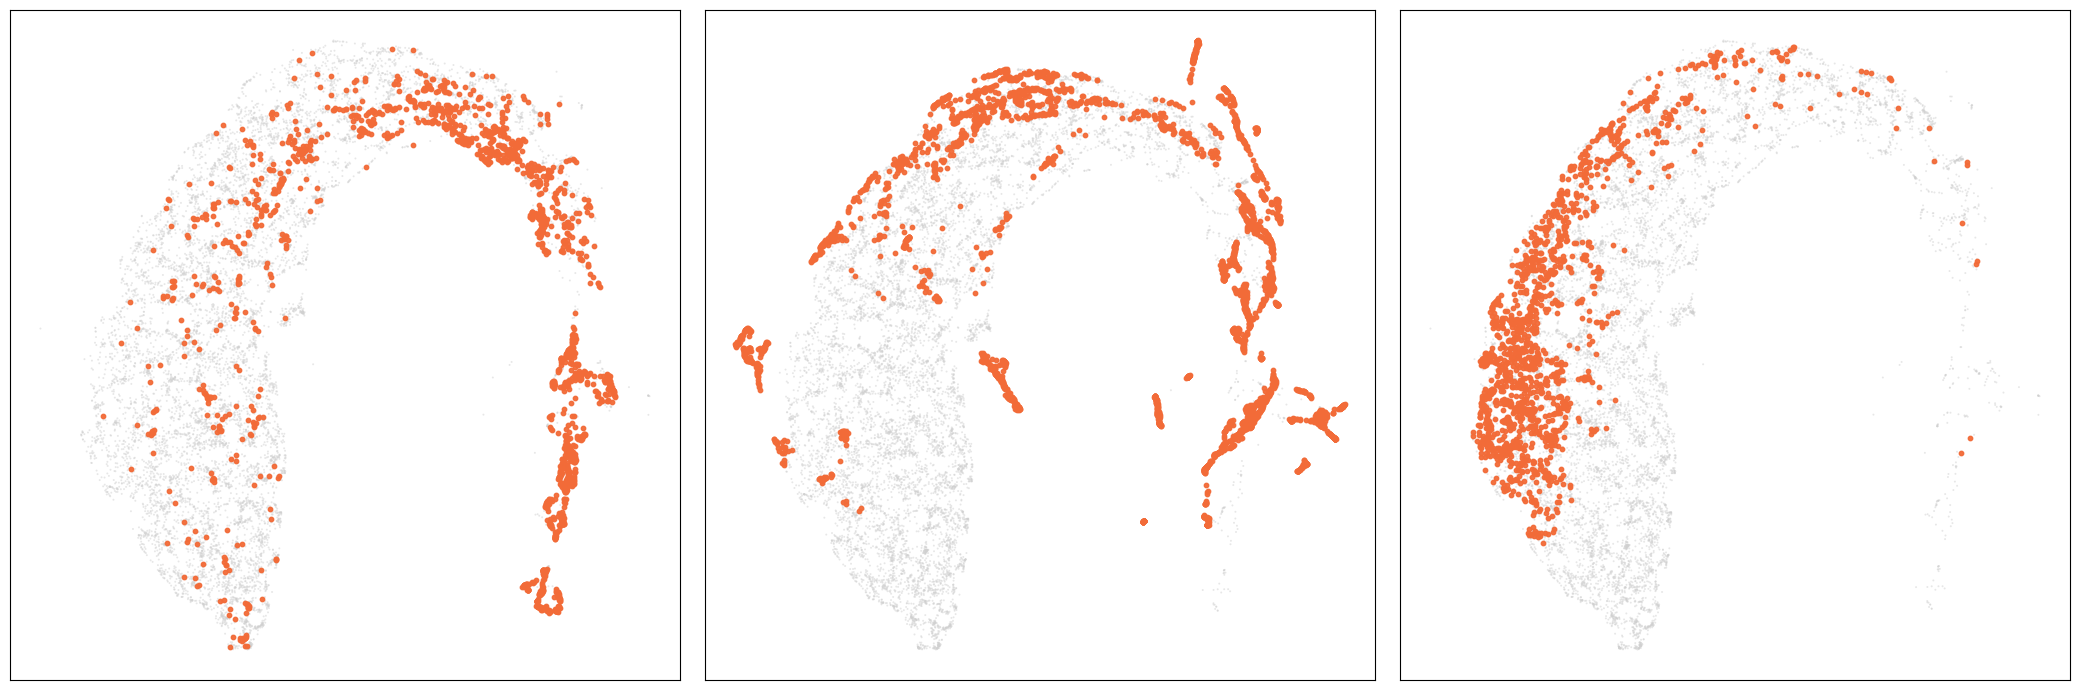


=== YIELD値でグラデーション色付けした可視化 ===
Buchwald-Hartwig, Suzuki-Miyaura, NiB


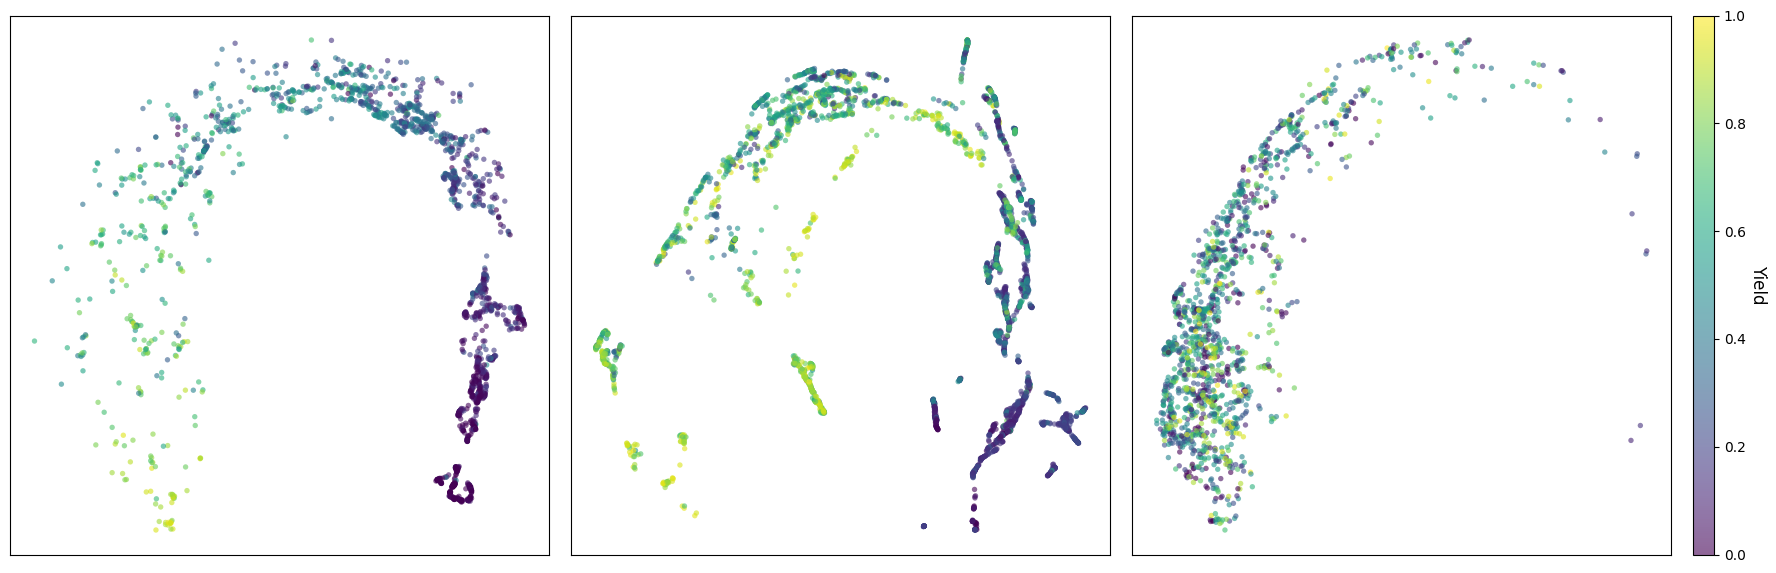

In [10]:
import seaborn as sns
import matplotlib.gridspec as gridspec

# すべてのデータセットの埋め込みを事前に1回だけUMAPで次元削減
all_embeddings_list = []
all_labels = []
all_yields = []

for name in ['Buchwald-Hartwig', 'Suzuki-Miyaura', 'NiB', 'ORD']:
    all_embeddings_list.append(embeddings[name])
    all_labels.extend([name] * len(embeddings[name]))
    
    if 'YIELD' in sampled_dfs[name].columns:
        all_yields.extend(sampled_dfs[name]['YIELD'].values / 100.0)
    else:
        all_yields.extend([0.5] * len(embeddings[name]))

combined_all_embeddings = np.concatenate(all_embeddings_list)
all_yields = np.array(all_yields)

# UMAPによる次元削減を1回だけ実行
print("UMAPによる次元削減を実行中...")
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d_all = reducer.fit_transform(combined_all_embeddings)
print("次元削減完了")

# UMAP結果をCSVに保存
umap_all_df = pd.DataFrame({
    'UMAP_1': embedding_2d_all[:, 0],
    'UMAP_2': embedding_2d_all[:, 1],
    'Dataset': all_labels,
    'YIELD': all_yields * 100
})
csv_path = Path('../runs/umap_results/All_Datasets.csv')
csv_path.parent.mkdir(parents=True, exist_ok=True)
umap_all_df.to_csv(csv_path, index=False)
print(f"UMAP結果を保存: {csv_path}")

# ORD以外のデータセット
other_datasets = ['Buchwald-Hartwig', 'Suzuki-Miyaura', 'NiB']

# データセットごとのインデックスを事前計算
dataset_indices = {}
current_idx = 0
for name in ['Buchwald-Hartwig', 'Suzuki-Miyaura', 'NiB', 'ORD']:
    dataset_size = len(embeddings[name])
    dataset_indices[name] = list(range(current_idx, current_idx + dataset_size))
    current_idx += dataset_size

# ==================== 従来版: データセットの種類で色分け ====================
print("\n=== データセットの種類で色分けした可視化 ===")
print("Buchwald-Hartwig, Suzuki-Miyaura, NiB")
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for idx, dataset_name in enumerate(other_datasets):
    ax = axes[idx]
    ord_idx = dataset_indices['ORD']
    other_idx = dataset_indices[dataset_name]

    ax.scatter(
        embedding_2d_all[ord_idx, 0], embedding_2d_all[ord_idx, 1],
        color='#D0D0D0', alpha=0.5, s=2, edgecolors='none', zorder=1
    )
    ax.scatter(
        embedding_2d_all[other_idx, 0], embedding_2d_all[other_idx, 1],
        color='#F26B38', alpha=0.95, s=10, zorder=2
    )
    ax.set_box_aspect(1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('')
    ax.grid(False)

plt.tight_layout()
plt.show()

# ==================== 新版: YIELD値でグラデーション ====================
print("\n=== YIELD値でグラデーション色付けした可視化 ===")
print("Buchwald-Hartwig, Suzuki-Miyaura, NiB")

# プロット3列 + カラーバー1列（細い）をGridSpecで定義
fig = plt.figure(figsize=(22, 7))
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.04], wspace=0.05)
axes = [fig.add_subplot(gs[i]) for i in range(3)]
cax = fig.add_subplot(gs[3])

last_scatter = None
for idx, dataset_name in enumerate(other_datasets):
    ax = axes[idx]
    other_idx = dataset_indices[dataset_name]

    scatter = ax.scatter(
        embedding_2d_all[other_idx, 0],
        embedding_2d_all[other_idx, 1],
        c=all_yields[other_idx],
        cmap='viridis',
        marker='o',
        alpha=0.6,
        s=15,
        edgecolors='none',
        zorder=1,
        vmin=0,
        vmax=1
    )
    last_scatter = scatter

    ax.set_box_aspect(1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('')
    ax.grid(False)

# カラーバーをGridSpec上の独立した列に配置
cbar = fig.colorbar(last_scatter, cax=cax, orientation='vertical')
cbar.set_label('Yield', fontsize=12, rotation=270, labelpad=15)

plt.show()